In [1]:

import os
import math
import random
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from torch.cuda.amp import autocast, GradScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH = '/kaggle/input/datasets/mohammadhossein77/ili-data/US_FLURATIO_Week.csv'
LOG_DIR   = '/kaggle/working/logs'
os.makedirs(LOG_DIR, exist_ok=True)


Device: cuda


# Init

In [2]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
LOOKBACK           = 36
HORIZON            = 12
MAX_LEN            = 256
BATCH_SIZE         = 4      # BERT memory constraint
ACCUMULATION_STEPS = 4      # effective batch = 16
EPOCHS             = 120
PATIENCE           = 10
WARMUP_EPOCHS      = 10
BERT_LR            = 1e-5
OTHER_LR           = 1e-5
SEED               = 42

# PatchTST config — identical to best unimodal run
PATCH_LEN  = 4
STRIDE     = 2     
D_MODEL    = 128
N_HEADS    = 8
NUM_LAYERS = 3
D_FF       = 256
DROPOUT    = 0.15


In [3]:
# ── Reproducibility ───────────────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

In [4]:

df = pd.read_csv(DATA_PATH)
print(f'Raw shape: {df.shape}')

# ── Text ──────────────────────────────────────────────────────────────────────
text_df          = pd.DataFrame()
text_df['facts'] = df['Final_Search_6']   # same source as DSA

# ── Numerical ─────────────────────────────────────────────────────────────────
numeric_df = df.iloc[:, :-4].copy()
numeric_df.drop(['date'], axis=1, inplace=True, errors='ignore')
numeric_df['start_date'] = pd.to_datetime(numeric_df['start_date'])
numeric_df['end_date']   = pd.to_datetime(numeric_df['end_date'])

numeric_df['WEEK_sin'] = np.sin(2 * np.pi * (numeric_df['WEEK'] / 52))
numeric_df['WEEK_cos'] = np.cos(2 * np.pi * (numeric_df['WEEK'] / 52))
numeric_df.drop(['WEEK'], axis=1, inplace=True)
numeric_df.drop(['REGION TYPE', 'REGION', 'YEAR_WEEK'],
                axis=1, inplace=True, errors='ignore')
numeric_df.drop(['prior_history_std', 'prior_history_avg'],
                axis=1, inplace=True, errors='ignore')
numeric_df = numeric_df.replace('X', np.nan)

num_features = [
    'YEAR', 'WEEK_sin', 'WEEK_cos',
    '% WEIGHTED ILI',
    'AGE 0-4', 'AGE 5-24',
    'AGE 25-49', 'AGE 25-64', 'AGE 50-64', 'AGE 65',
    'ILITOTAL', 'NUM. OF PROVIDERS', 'TOTAL PATIENTS'
]
numeric_df[num_features] = numeric_df[num_features].apply(
    pd.to_numeric, errors='coerce')

merged_df = pd.concat([numeric_df, text_df], axis=1)
merged_df.sort_values('start_date', inplace=True)
print(f'Merged shape: {merged_df.shape}')



Raw shape: (1389, 25)
Merged shape: (1389, 17)


In [5]:
# ── Split ─────────────────────────────────────────────────────────────────────
n          = len(merged_df)
train_size = int(n * 0.8)
val_size   = int(n * 0.1)

train_df = merged_df.iloc[:train_size].copy()
val_df   = merged_df.iloc[train_size : train_size + val_size].copy()
test_df  = merged_df.iloc[train_size + val_size:].copy()
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

# ── Age imputation ────────────────────────────────────────────────────────────
for dff in [train_df, val_df, test_df]:
    mask_split = (dff['AGE 25-49'].isna() &
                  dff['AGE 50-64'].isna() &
                  ~dff['AGE 25-64'].isna())
    dff.loc[mask_split, 'AGE 25-49'] = dff.loc[mask_split, 'AGE 25-64'] * 0.6
    dff.loc[mask_split, 'AGE 50-64'] = dff.loc[mask_split, 'AGE 25-64'] * 0.4

    mask_comb = (~dff['AGE 25-49'].isna() &
                 ~dff['AGE 50-64'].isna() &
                 dff['AGE 25-64'].isna())
    dff.loc[mask_comb, 'AGE 25-64'] = (dff.loc[mask_comb, 'AGE 25-49'] +
                                        dff.loc[mask_comb, 'AGE 50-64'])

print('NaNs after imputation (train):')
print(train_df[num_features].isna().sum())



Train: 1111 | Val: 138 | Test: 140
NaNs after imputation (train):
YEAR                 0
WEEK_sin             0
WEEK_cos             0
% WEIGHTED ILI       0
AGE 0-4              0
AGE 5-24             0
AGE 25-49            0
AGE 25-64            0
AGE 50-64            0
AGE 65               0
ILITOTAL             0
NUM. OF PROVIDERS    0
TOTAL PATIENTS       0
dtype: int64


In [6]:
# ── Scaling ───────────────────────────────────────────────────────────────────
feature_scaler = MinMaxScaler()
train_df[num_features] = feature_scaler.fit_transform(train_df[num_features])
val_df[num_features]   = feature_scaler.transform(val_df[num_features])
test_df[num_features]  = feature_scaler.transform(test_df[num_features])
joblib.dump(feature_scaler,
            os.path.join(LOG_DIR, 'patchtst_bert_feature_scaler.pkl'))

target_scaler = MinMaxScaler()
train_df['OT'] = target_scaler.fit_transform(
    train_df['OT'].values.reshape(-1, 1)).flatten()
val_df['OT']   = target_scaler.transform(
    val_df['OT'].values.reshape(-1, 1)).flatten()
test_df['OT']  = target_scaler.transform(
    test_df['OT'].values.reshape(-1, 1)).flatten()
joblib.dump(target_scaler,
            os.path.join(LOG_DIR, 'patchtst_bert_target_scaler.pkl'))

if 'OT' not in num_features:
    num_features.append('OT')
print(f'Total numerical features (incl. OT): {len(num_features)}')  # 14



Total numerical features (incl. OT): 14


In [7]:
# ── Sequence creation ─────────────────────────────────────────────────────────
def create_sequences(df, lookback, horizon):
    df = df.sort_values('start_date').reset_index(drop=True)
    X_num, X_text, y = [], [], []
    for i in range(len(df) - lookback - horizon + 1):
        X_num.append(df[num_features].iloc[i : i + lookback].values)
        X_text.append(df['facts'].iloc[i : i + lookback].tolist())
        y.append(df['OT'].iloc[i + lookback : i + lookback + horizon].values)
    return (np.array(X_num,  dtype=np.float32),
            np.array(X_text, dtype=object),
            np.array(y,      dtype=np.float32))


val_df_full  = pd.concat([train_df.iloc[-LOOKBACK:], val_df],  ignore_index=True)
test_df_full = pd.concat([val_df.iloc[-LOOKBACK:],  test_df],  ignore_index=True)

X_num_train, X_text_train, y_train = create_sequences(train_df,     LOOKBACK, HORIZON)
X_num_val,   X_text_val,   y_val   = create_sequences(val_df_full,  LOOKBACK, HORIZON)
X_num_test,  X_text_test,  y_test  = create_sequences(test_df_full, LOOKBACK, HORIZON)

print(f'Train : {X_num_train.shape} -> {y_train.shape}')
print(f'Val   : {X_num_val.shape}   -> {y_val.shape}')
print(f'Test  : {X_num_test.shape}  -> {y_test.shape}')


Train : (1064, 36, 14) -> (1064, 12)
Val   : (127, 36, 14)   -> (127, 12)
Test  : (129, 36, 14)  -> (129, 12)


In [8]:
# ── Tokenization ──────────────────────────────────────────────────────────────
def tokenize_sequences(sequences, tokenizer, max_len=256):
    tokenized = []
    for sample in tqdm(sequences, desc='Tokenizing'):
        enc = tokenizer(
            sample.tolist(),
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        tokenized.append({
            'input_ids':      enc['input_ids'],      # (36, 256)
            'attention_mask': enc['attention_mask']  # (36, 256)
        })
    return tokenized


tokenizer = AutoTokenizer.from_pretrained('michiyasunaga/BioLinkBERT-base')

X_text_train_tok = tokenize_sequences(X_text_train, tokenizer, MAX_LEN)
X_text_val_tok   = tokenize_sequences(X_text_val,   tokenizer, MAX_LEN)
X_text_test_tok  = tokenize_sequences(X_text_test,  tokenizer, MAX_LEN)
print(f'Tokenized — Train: {len(X_text_train_tok)} samples')


config.json:   0%|          | 0.00/559 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/379 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizing: 100%|██████████| 129/129 [00:05<00:00, 22.83it/s]

Tokenized — Train: 1064 samples


In [9]:


class MultimodalDataset(Dataset):
    def __init__(self, X_num, X_text_tok, y):
        self.X_num  = torch.tensor(X_num, dtype=torch.float32)
        self.X_text = X_text_tok
        self.y      = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X_num)

    def __getitem__(self, idx):
        return self.X_num[idx], self.X_text[idx], self.y[idx]


train_loader = DataLoader(
    MultimodalDataset(X_num_train, X_text_train_tok, y_train),
    batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(
    MultimodalDataset(X_num_val, X_text_val_tok, y_val),
    batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(
    MultimodalDataset(X_num_test, X_text_test_tok, y_test),
    batch_size=BATCH_SIZE, shuffle=False)

print(f'Batches — Train: {len(train_loader)} | '
      f'Val: {len(val_loader)} | Test: {len(test_loader)}')



Batches — Train: 266 | Val: 32 | Test: 33


# PatchTST

In [10]:

class PatchTSTBERT(nn.Module):
    """
    Naive multimodal baseline:
      - PatchTST for numerical forecasting (patch-based attention)
      - BioLinkBERT-base (last 8 layers unfrozen, same policy as DSA)
      - Simple sum fusion (no cross-modal attention)
    PatchTST config matches best unimodal run: patch_len=6, stride=2.
    """
    def __init__(self,
                 seq_len      = 36,
                 horizon      = 12,
                 num_channels = 14,
                 patch_len    = 6,
                 stride       = 2,
                 d_model      = 128,
                 n_heads      = 4,
                 num_layers   = 3,
                 d_ff         = 256,
                 dropout      = 0.15):
        super().__init__()

        self.num_patches  = (seq_len - patch_len) // stride + 1
        self.patch_len    = patch_len
        self.stride       = stride
        self.num_channels = num_channels
        self.ot_idx       = num_channels - 1   # OT is last column

        print(f'  PatchTST num_patches: {self.num_patches}')  # should be 16

        # ── Numerical path (PatchTST) ─────────────────────────────────────────
        self.patch_proj = nn.Linear(patch_len, d_model)

        self.pos_emb = nn.Parameter(
            torch.zeros(1, self.num_patches, d_model))
        nn.init.trunc_normal_(self.pos_emb, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = n_heads,
            dim_feedforward = d_ff,
            dropout         = dropout,
            batch_first     = True,
            norm_first      = True,   # Pre-LN — PatchTST default
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(d_model)

        # Prediction head: flatten patches → forecast (OT channel only)
        self.num_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.num_patches * d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, horizon),
        )

        # ── Text path (BioLinkBERT) ───────────────────────────────────────────
        self.bert = AutoModel.from_pretrained('michiyasunaga/BioLinkBERT-base')

        # Freeze all, then unfreeze last 8 layers — identical policy to DSA
        for param in self.bert.parameters():
            param.requires_grad = False
        for param in self.bert.encoder.layer[-8:].parameters():
            param.requires_grad = True

        self.text_proj = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, horizon),
        )

    def forward(self, X_num, input_ids, attention_mask):
        """
        X_num          : (B, T, C)
        input_ids      : (B, T, L)
        attention_mask : (B, T, L)
        Returns        : (B, horizon)
        """
        B, T, L = input_ids.shape

        # ── Numerical path ────────────────────────────────────────────────────
        x = X_num.transpose(1, 2)              # (B, C, T)
        x = x.unfold(dimension=2,
                     size=self.patch_len,
                     step=self.stride)          # (B, C, num_patches, patch_len)
        x = x.reshape(B * self.num_channels,
                       self.num_patches,
                       self.patch_len)          # (B*C, num_patches, patch_len)
        x = self.patch_proj(x)                 # (B*C, num_patches, d_model)
        x = x + self.pos_emb                   # (B*C, num_patches, d_model)
        x = self.transformer(x)                # (B*C, num_patches, d_model)
        x = self.norm(x)                       # (B*C, num_patches, d_model)
        x = self.num_head(x)                   # (B*C, horizon)
        x = x.reshape(B, self.num_channels, -1)  # (B, C, horizon)
        num_out = x[:, self.ot_idx, :]         # (B, horizon) — OT only

        # ── Text path ─────────────────────────────────────────────────────────
        flat_ids  = input_ids.view(B * T, L)
        flat_mask = attention_mask.view(B * T, L)

        bert_out  = self.bert(input_ids=flat_ids, attention_mask=flat_mask)
        cls_emb   = bert_out.last_hidden_state[:, 0, :]   # (B*T, 768)
        cls_emb   = cls_emb.view(B, T, 768)               # (B, T, 768)

        text_ctx  = cls_emb.mean(dim=1)                   # (B, 768)
        text_out  = self.text_proj(text_ctx)               # (B, horizon)

        # ── Naive sum fusion ──────────────────────────────────────────────────
        return num_out + text_out                          # (B, horizon)




In [11]:

model = PatchTSTBERT(
    seq_len      = LOOKBACK,
    horizon      = HORIZON,
    num_channels = len(num_features),  # 14
    patch_len    = PATCH_LEN,
    stride       = STRIDE,
    d_model      = D_MODEL,
    n_heads      = N_HEADS,
    num_layers   = NUM_LAYERS,
    d_ff         = D_FF,
    dropout      = DROPOUT,
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / Total: {total:,}')

# Separate BERT and non-BERT params — same split as DSA and other multimodal baselines
bert_params    = list(model.bert.parameters())
bert_param_ids = {id(p) for p in bert_params}
other_params   = [p for p in model.parameters()
                  if id(p) not in bert_param_ids]

optimizer = torch.optim.AdamW([
    {'params': bert_params,  'lr': BERT_LR,  'weight_decay': 1e-4},
    {'params': other_params, 'lr': OTHER_LR, 'weight_decay': 1e-4},
])

updates_per_epoch = math.ceil(len(train_loader) / ACCUMULATION_STEPS)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = WARMUP_EPOCHS * updates_per_epoch,
    num_training_steps = EPOCHS        * updates_per_epoch,
)

criterion  = nn.MSELoss()
amp_scaler = GradScaler()



  PatchTST num_patches: 17


/tmp/ipykernel_23/2653843473.py:45: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: michiyasunaga/BioLinkBERT-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Trainable: 57,583,640 / Total: 109,113,368


/tmp/ipykernel_23/3858309391.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = GradScaler()


# Training ...

In [12]:


history         = {'epoch': [], 'train_loss': [], 'val_loss': []}
best_val_loss   = float('inf')
best_model_path = os.path.join(LOG_DIR, 'patchtst_bert_best.pth')
p_counter       = 0

for epoch in tqdm(range(EPOCHS)):

    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    optimizer.zero_grad()
    epoch_train_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        X_num_b = batch[0].to(device)
        text_b  = {k: v.to(device) for k, v in batch[1].items()}
        targets = batch[2].to(device)

        with autocast():
            preds = model(X_num_b,
                          text_b['input_ids'],
                          text_b['attention_mask'])
            loss = criterion(preds, targets) / ACCUMULATION_STEPS

        amp_scaler.scale(loss).backward()

        if ((batch_idx + 1) % ACCUMULATION_STEPS == 0 or
                (batch_idx + 1) == len(train_loader)):
            amp_scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            amp_scaler.step(optimizer)
            amp_scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        epoch_train_loss += loss.item() * ACCUMULATION_STEPS

    avg_train = epoch_train_loss / len(train_loader)

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            X_num_b = batch[0].to(device)
            text_b  = {k: v.to(device) for k, v in batch[1].items()}
            targets = batch[2].to(device)
            with autocast():
                preds     = model(X_num_b,
                                  text_b['input_ids'],
                                  text_b['attention_mask'])
                val_loss += criterion(preds, targets).item()

    avg_val = val_loss / len(val_loader)

    history['epoch'].append(epoch)
    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        p_counter     = 0
        torch.save(model.state_dict(), best_model_path)
        print(f'  ↓ New best at epoch {epoch} | val={avg_val:.6f}')
    else:
        if epoch >= WARMUP_EPOCHS:
            p_counter += 1
            if p_counter >= PATIENCE:
                print(f'Early stopping at epoch {epoch}')
                break

    if epoch % 10 == 0 or epoch < 5:
        print(f'Epoch {epoch:3d} | Train: {avg_train:.6f} | Val: {avg_val:.6f}')

print(f'\nBest val loss : {best_val_loss:.6f}')
print(f'Checkpoint    : {best_model_path}')




  0%|          | 0/120 [00:00<?, ?it/s]/tmp/ipykernel_23/590007763.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_23/590007763.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():

  1%|          | 1/120 [05:22<10:39:45, 322.57s/it]

  ↓ New best at epoch 0 | val=0.086407
Epoch   0 | Train: 0.109648 | Val: 0.086407



  2%|▏         | 2/120 [10:53<10:44:24, 327.67s/it]

  ↓ New best at epoch 1 | val=0.052354
Epoch   1 | Train: 0.040968 | Val: 0.052354



  2%|▎         | 3/120 [16:26<10:43:11, 329.84s/it]

...

  ↓ New best at epoch 15 | val=0.033943



 18%|█▊        | 21/120 [1:55:08<9:00:01, 327.28s/it]

Epoch  20 | Train: 0.008200 | Val: 0.037820



 21%|██        | 25/120 [2:22:26<9:01:16, 341.85s/it]

Early stopping at epoch 25

Best val loss : 0.033943
Checkpoint    : /kaggle/working/logs/patchtst_bert_best.pth


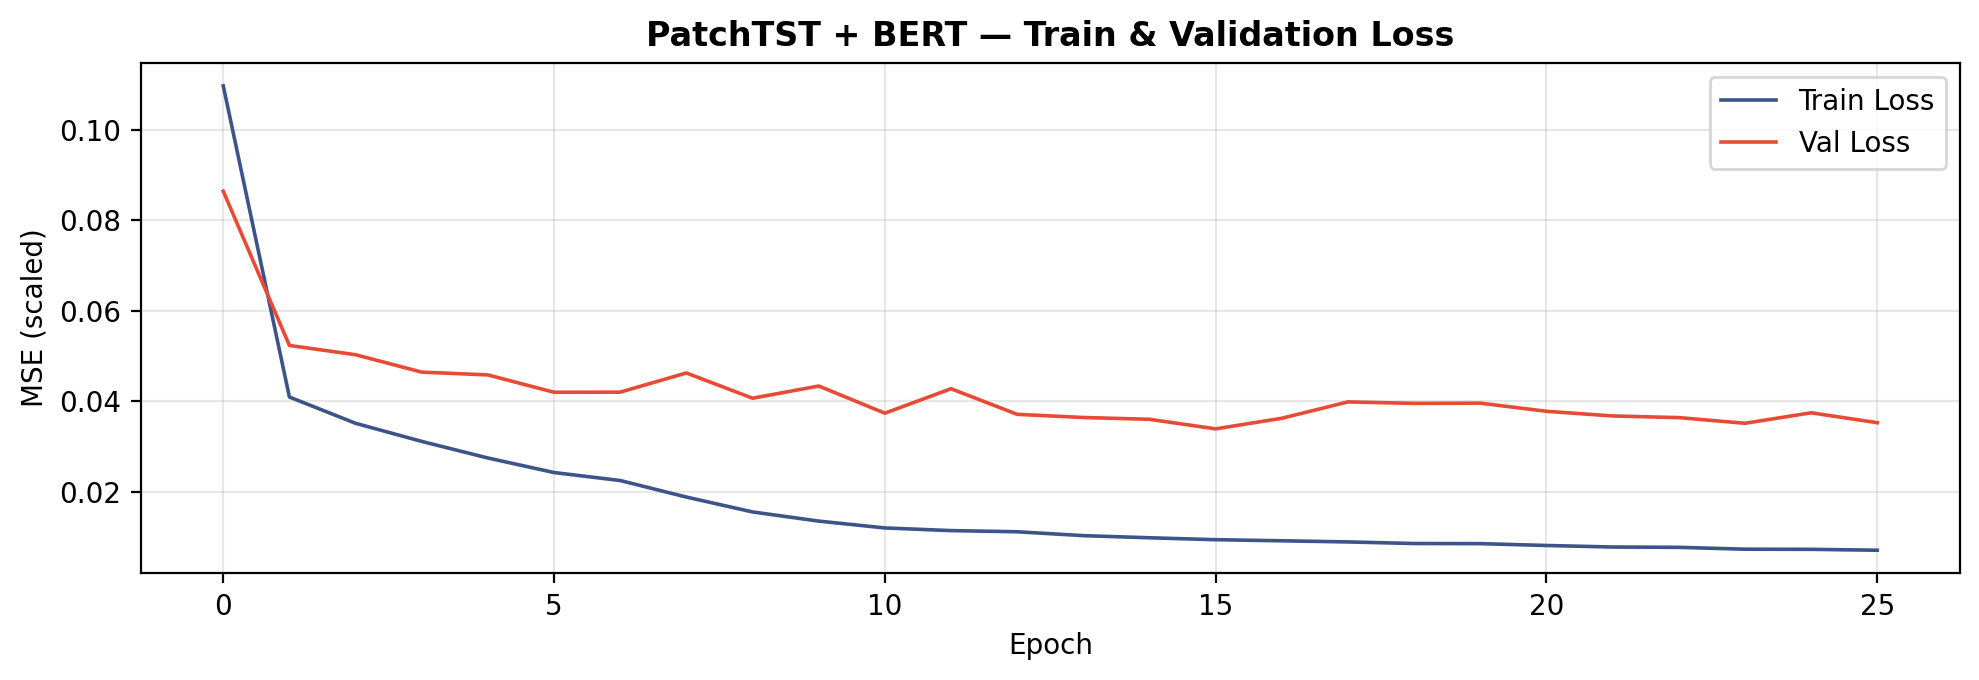

In [13]:
mpl.rcParams.update({'font.family': 'DejaVu Sans',
                     'axes.facecolor': 'white', 'figure.facecolor': 'white'})
plt.figure(figsize=(10, 3.5), dpi=200)
plt.plot(history['epoch'], history['train_loss'],
         color='#3C5488', label='Train Loss', linewidth=1.3)
plt.plot(history['epoch'], history['val_loss'],
         color='#E64B35', label='Val Loss',   linewidth=1.3)
plt.xlabel('Epoch'); plt.ylabel('MSE (scaled)')
plt.title('PatchTST + BERT — Train & Validation Loss', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'{LOG_DIR}/patchtst_bert_loss_curve.png',
            dpi=300, bbox_inches='tight')
plt.show()



In [14]:

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

test_preds, test_targets = [], []
with torch.no_grad():
    for batch in test_loader:
        X_num_b = batch[0].to(device)
        text_b  = {k: v.to(device) for k, v in batch[1].items()}
        targets = batch[2]
        with autocast():
            preds = model(X_num_b,
                          text_b['input_ids'],
                          text_b['attention_mask'])
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(targets.numpy())

test_preds   = np.array(test_preds)    # (N, 12)
test_targets = np.array(test_targets)  # (N, 12)

inv_preds   = target_scaler.inverse_transform(
    test_preds.reshape(-1, 1)).reshape(-1, HORIZON)
inv_targets = target_scaler.inverse_transform(
    test_targets.reshape(-1, 1)).reshape(-1, HORIZON)

mse_val  = mean_squared_error(inv_targets.flatten(), inv_preds.flatten())
mae_val  = mean_absolute_error(inv_targets.flatten(), inv_preds.flatten())
rmse_val = np.sqrt(mse_val)

print('=' * 60)
print(f'  PatchTST+BERT  (naive)  | Test MSE : {mse_val:.4f}')
print(f'                          | Test MAE : {mae_val:.4f}')
print(f'                          | Test RMSE: {rmse_val:.4f}  (inverse-scaled)')
print(f'  PatchTST (unimodal)     | Test MSE : 1.55   (ref)')
print(f'  iTransformer+BERT naive | Test MSE : 2.4165 (ref)')
print(f'  DLinear+BERT  naive     | Test MSE : 2.2620 (ref)')
print(f'  DSA (mean / best)       | Test MSE : 1.120 ± 0.096 / 0.9749')
print('=' * 60)



/tmp/ipykernel_23/4041213566.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  PatchTST+BERT  (naive)  | Test MSE : 2.9825
                          | Test MAE : 1.4020
                          | Test RMSE: 1.7270  (inverse-scaled)
  PatchTST (unimodal)     | Test MSE : 1.55   (ref)
  iTransformer+BERT naive | Test MSE : 2.4165 (ref)
  DLinear+BERT  naive     | Test MSE : 2.2620 (ref)
  DSA (mean / best)       | Test MSE : 1.120 ± 0.096 / 0.9749


In [15]:
# ── Per-sample & per-horizon errors ───────────────────────────────────────────
per_sample_mse  = ((inv_preds - inv_targets) ** 2).mean(axis=1)   # (N,)
per_horizon_mse = ((inv_preds - inv_targets) ** 2).mean(axis=0)   # (12,)

np.save(f'{LOG_DIR}/errors_patchtst_bert.npy',  per_sample_mse)
np.save(f'{LOG_DIR}/horizon_patchtst_bert.npy', per_horizon_mse)
np.save(f'{LOG_DIR}/preds_patchtst_bert.npy',   inv_preds)
np.save(f'{LOG_DIR}/targets_patchtst_bert.npy', inv_targets)

print('\nPer-horizon MSE (weeks 1–12):')
for h, hmse in enumerate(per_horizon_mse, 1):
    print(f'  Week {h:2d}: {hmse:.4f}')




Per-horizon MSE (weeks 1–12):
  Week  1: 1.9430
  Week  2: 2.2159
  Week  3: 2.1820
  Week  4: 3.3896
  Week  5: 2.7986
  Week  6: 3.6304
  Week  7: 3.3382
  Week  8: 3.6673
  Week  9: 3.6764
  Week 10: 2.8971
  Week 11: 2.9217
  Week 12: 3.1294


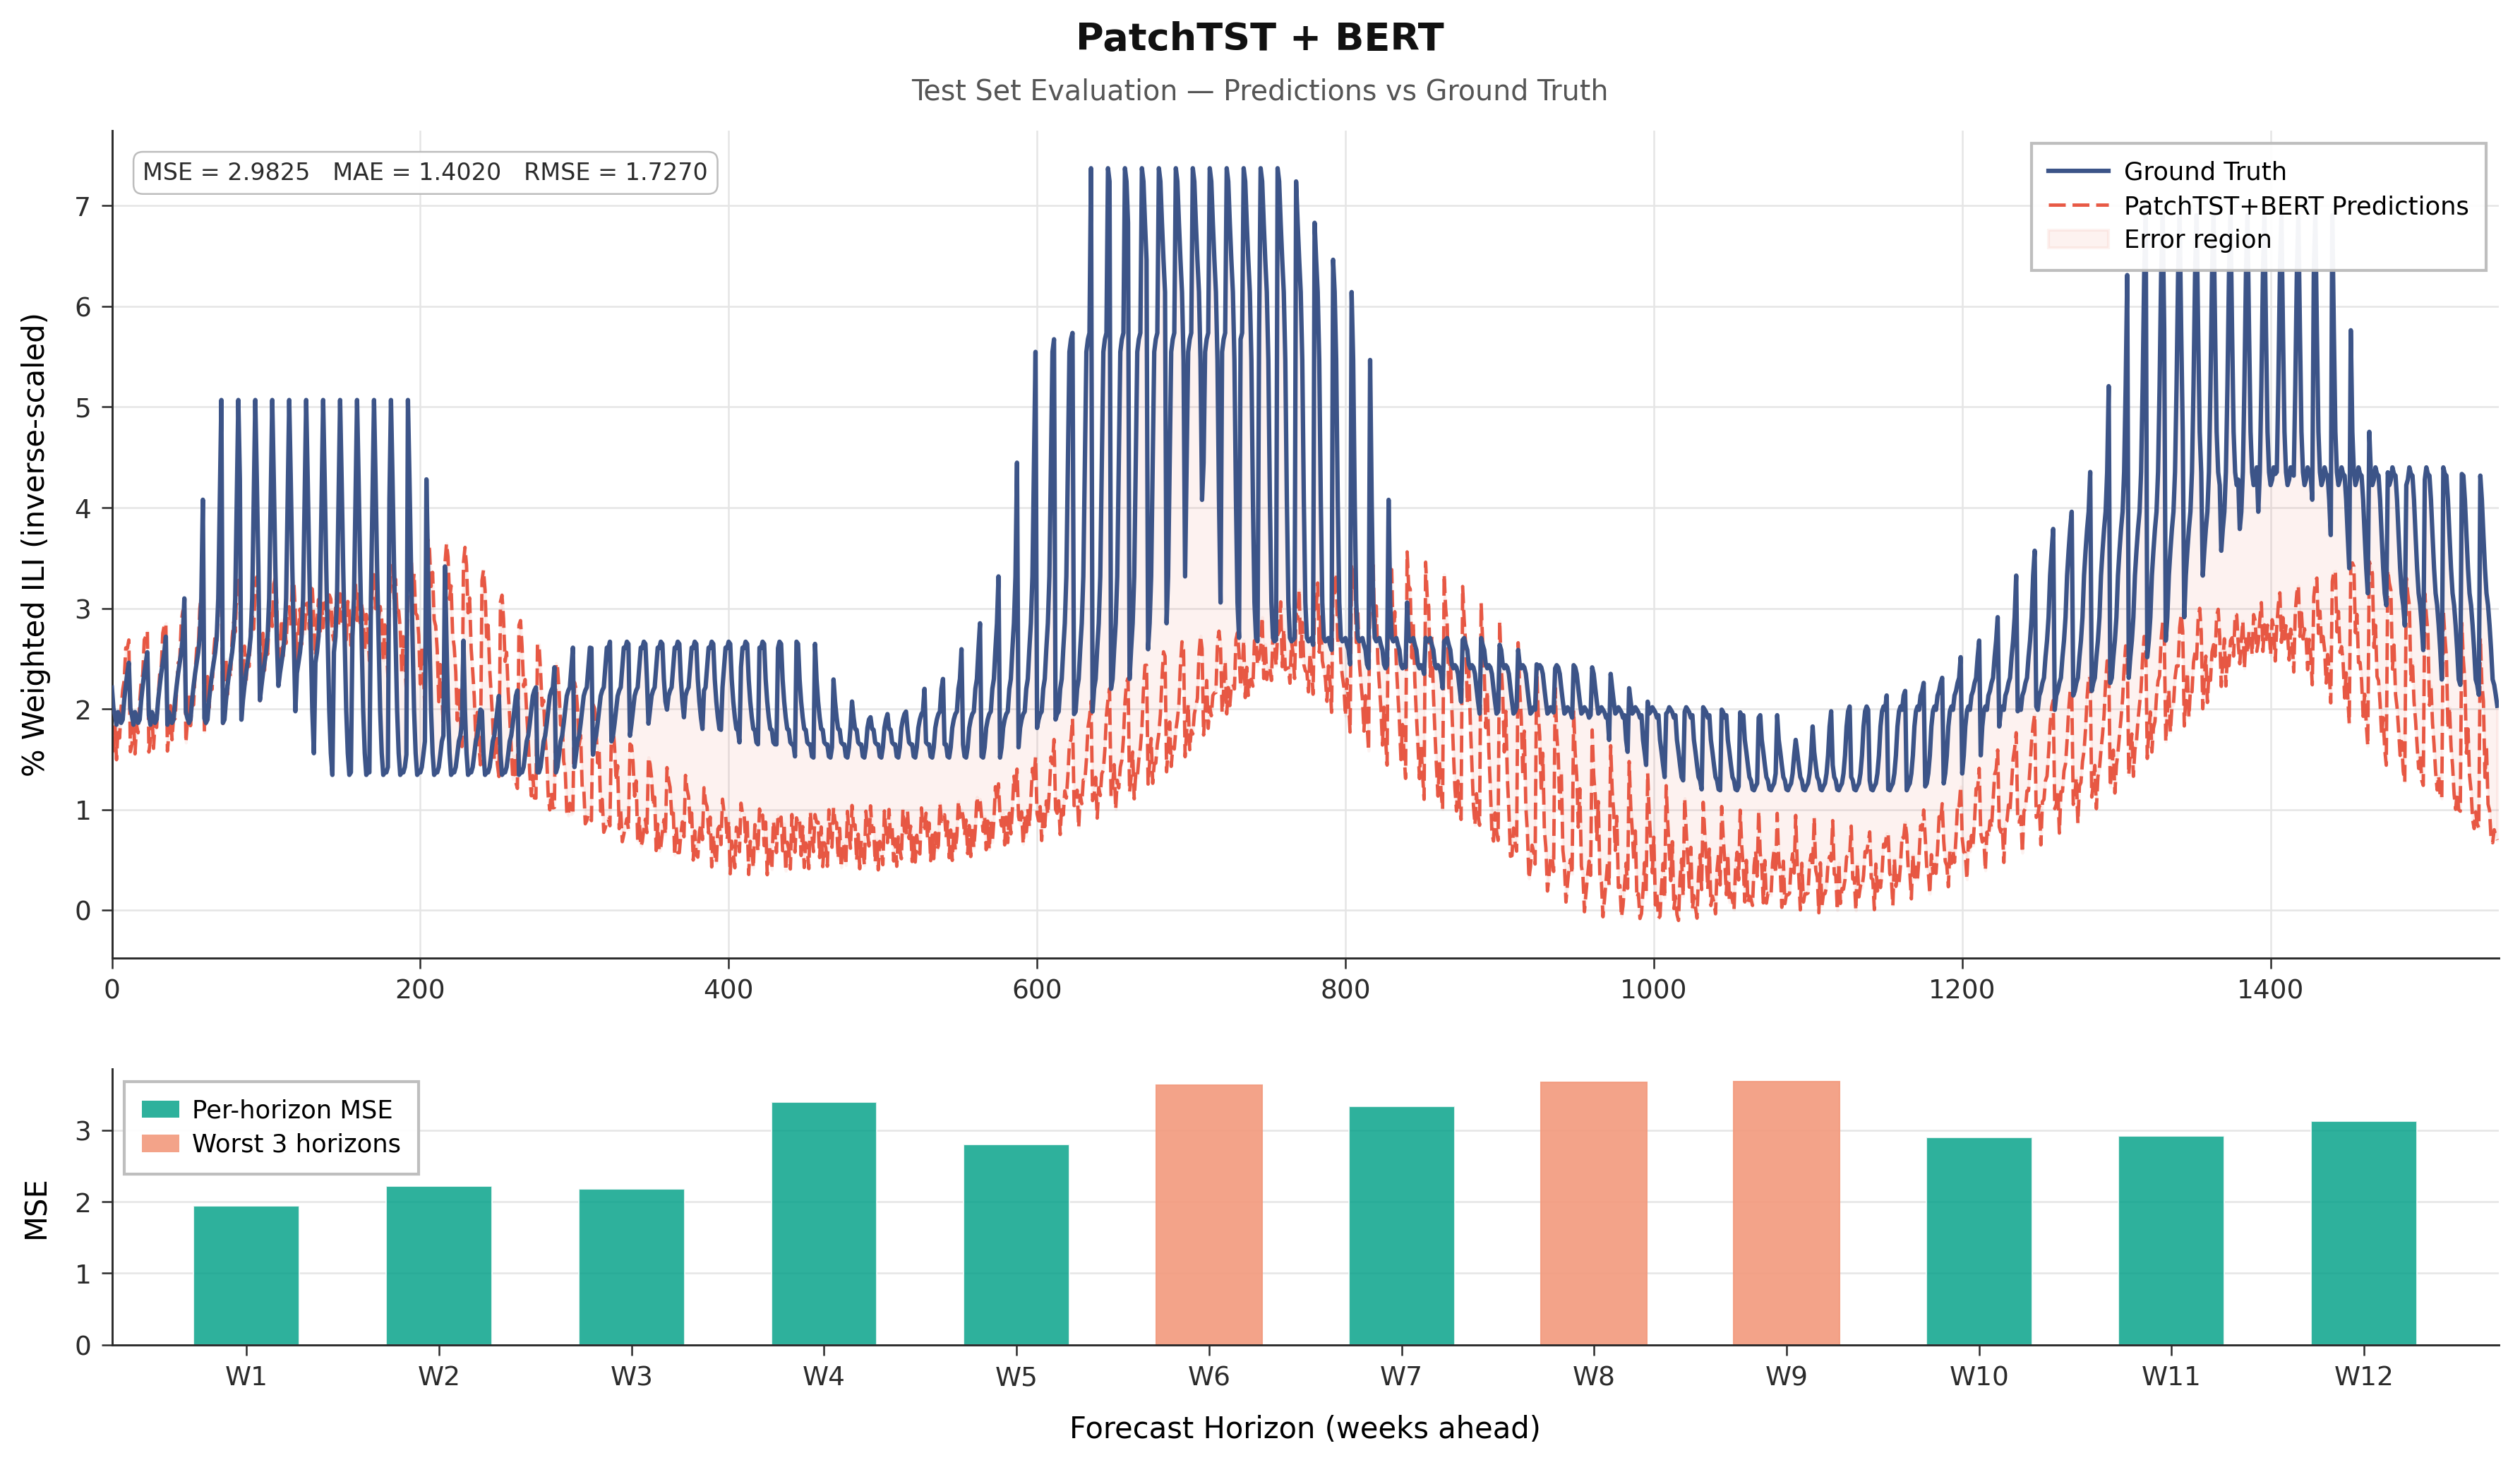

Done. All outputs saved to /kaggle/working/logs


In [16]:
# Same viz as the rest of them
C_TRUTH  = '#3C5488'
C_PRED   = '#E64B35'
C_FILL   = '#E64B35'
C_BAR    = '#00A087'
C_WORST  = '#F39B7F'
C_GRID   = '#E5E5E5'

mpl.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.linewidth': 0.7,  'axes.edgecolor': '#2B2B2B',
    'axes.facecolor': 'white', 'figure.facecolor': 'white',
    'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
    'xtick.major.size': 3.5,  'ytick.major.size': 3.5,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'xtick.color': '#2B2B2B', 'ytick.color': '#2B2B2B',
    'legend.framealpha': 0.95, 'legend.edgecolor': '#BBBBBB',
    'legend.fancybox': False,
})

flat_targets = inv_targets.flatten()
flat_preds   = inv_preds.flatten()
timesteps    = np.arange(len(flat_targets))

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 6.5), dpi=300,
    gridspec_kw={'height_ratios': [3, 1]}
)
fig.text(0.5, 1.03, 'PatchTST + BERT',
         ha='center', va='bottom',
         fontsize=13, fontweight='bold', color='#111111')
fig.text(0.5, 0.995, 'Test Set Evaluation — Predictions vs Ground Truth',
         ha='center', va='bottom',
         fontsize=9.5, fontweight='normal', color='#555555')

ax1.plot(timesteps, flat_targets,
         color=C_TRUTH, linewidth=1.5, alpha=1.0,
         label='Ground Truth', zorder=3)
ax1.plot(timesteps, flat_preds,
         color=C_PRED, linewidth=1.15, linestyle='--', dashes=(5, 2),
         alpha=0.92, label='PatchTST+BERT Predictions', zorder=2)
ax1.fill_between(timesteps, flat_targets, flat_preds,
                 color=C_FILL, alpha=0.07, zorder=1, label='Error region')
ax1.set_ylabel('% Weighted ILI (inverse-scaled)', fontsize=10, labelpad=8)
ax1.set_xlim(0, len(flat_targets))
ax1.grid(True, color=C_GRID, linewidth=0.6)
ax1.set_axisbelow(True)
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='both', labelsize=9)
ax1.legend(loc='upper right', fontsize=8.5, handlelength=2.4,
           handletextpad=0.6, borderpad=0.7, labelspacing=0.4)
ax1.text(0.013, 0.963,
         f'MSE = {mse_val:.4f}   MAE = {mae_val:.4f}   RMSE = {rmse_val:.4f}',
         transform=ax1.transAxes, fontsize=8,
         verticalalignment='top', color='#2B2B2B',
         bbox=dict(boxstyle='round,pad=0.40', facecolor='white',
                   edgecolor='#BBBBBB', linewidth=0.6, alpha=0.97))

horizon_steps = np.arange(1, 13)
bars = ax2.bar(horizon_steps, per_horizon_mse,
               color=C_BAR, alpha=0.82, width=0.55,
               edgecolor='white', linewidth=0.5, zorder=2)
top3_idx = np.argsort(per_horizon_mse)[-3:]
for idx in top3_idx:
    bars[idx].set_color(C_WORST)
    bars[idx].set_alpha(0.92)
ax2.set_xlabel('Forecast Horizon (weeks ahead)', fontsize=10, labelpad=8)
ax2.set_ylabel('MSE', fontsize=10, labelpad=8)
ax2.set_xticks(horizon_steps)
ax2.set_xticklabels([f'W{h}' for h in horizon_steps], fontsize=8.5)
ax2.grid(axis='y', color=C_GRID, linewidth=0.6)
ax2.set_axisbelow(True)
ax2.set_xlim(0.3, 12.7)
ax2.tick_params(axis='both', labelsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(handles=[
    Patch(facecolor=C_BAR,   alpha=0.82, label='Per-horizon MSE'),
    Patch(facecolor=C_WORST, alpha=0.92, label='Worst 3 horizons'),
], fontsize=8.5, loc='upper left', handlelength=1.5,
   handletextpad=0.5, borderpad=0.7, labelspacing=0.4)

plt.tight_layout(h_pad=2.2)
plt.savefig(f'{LOG_DIR}/patchtst_bert_test_evaluation.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Done. All outputs saved to', LOG_DIR)